In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

# Load CovFit model

In [4]:
TOK_DIR = "./covfit_stuff/Tokenizer"
CONF_DIR = "./covfit_stuff/Config"
TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt"
FOLD_ID = 0
N_TARGETS = 1565
MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt"

In [5]:
# MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
# FOLD_IDS_TO_USE = [0]
# TARGET_FOLD_ID = 0
# OUTPUT_PREFIX = "inference_results"

model_name = "facebook/esm2_t33_650M_UR50D"
device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [6]:
def get_model(
    TOK_DIR = "./covfit_stuff/Tokenizer",
    CONF_DIR = "./covfit_stuff/Config",
    TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt",
    FOLD_ID = 0,
    N_TARGETS = 1565,
    MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt",
    device=device
):
    esm_config = EsmConfig.from_pretrained(CONF_DIR)
    model = EsmForRegression(esm_config, N_TARGETS).to(device)

    lora_config = LoraConfig(
        task_type="SEQ_CLS",
        r=8,
        lora_alpha=16,
        target_modules=["key", "query", "value","dense"],
        lora_dropout=0.05,
        bias="lora_only",
        modules_to_save=["regressor"]
    )
    esm_fine_tuned = get_peft_model(model, lora_config)
    state_dict = torch.load(MODEL_PATH, map_location=device)
    
    # keys_to_remove = []
    # for key in state_dict.keys():
    #     if 'contact_head' in key:
    #         keys_to_remove.append(key)
    
    # for key in keys_to_remove:
    #     del state_dict[key]

    wrong_keys = [key for key in state_dict.keys() if key not in esm_fine_tuned.state_dict().keys()]
    key_list = list(state_dict.keys())
    for key in key_list:
        if key in wrong_keys:
            correct_key = key.rsplit('.',1)[0]+'.base_layer.'+key.rsplit('.',1)[1]
            state_dict[correct_key] = state_dict.pop(key)

    del state_dict["base_model.model.esm.embeddings.position_embeddings.base_layer.weight"]
    
    esm_fine_tuned.load_state_dict(state_dict)
    esm_fine_tuned = esm_fine_tuned.merge_and_unload()
    esm_fine_tuned.eval()
    esm_fine_tuned.esm.embeddings.token_dropout = False

    return esm_fine_tuned

In [7]:
esm_fine_tuned = get_model()

In [8]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [9]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name
REPO_ID = esm_config.model_name
original_task_id_infos = torch.load("./covfit_stuff/task_id_dict.pt", map_location=device)

In [10]:
tokenizer_config = {}
special_tokens_map_file = "./covfit_stuff/Tokenizer/special_tokens_map.json"
tokenizer_config["vocab_file"] = "./covfit_stuff/Tokenizer/vocab.txt"
tokenizer_config["model_max_length"] = CONTEXT_LEN

with open("./covfit_stuff/Tokenizer/special_tokens_map.json", "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [11]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

In [12]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

hooked_esm.tokenizer = tokenizer
print("assigned tokenizer to ESM model")

<All keys matched successfully>
assigned tokenizer to ESM model


In [13]:
# clean up memory
torch.cuda.empty_cache()

# Load Data

In [14]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [15]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [16]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [17]:
"""
uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4404
torch.Size([4404, 1024])


In [18]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [19]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [20]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [21]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

In [22]:
logit_id = original_task_id_infos["fitness_USA"]

# Curating new fitness with low-mutation dataset

# L455F mutation

In [85]:
# Making big dataset of L455,F455 seqs.
##########################################
# adding data with FLip mutation (L455F)
N=455
L455_seqs = [x for x in all_uniq_seqs if x[N-1] == "L"]
F455_seqs = [x[:N-1] + "F" + x[N:] for x in L455_seqs]

# dump into json dir
num_seqs = 60
snmf_seq_dataset_path = "../../data/snmf_seqs.json"
with open(snmf_seq_dataset_path, "w") as f:
    json.dump({"":[*L455_seqs[:num_seqs], *F455_seqs[:num_seqs]]}, f)


enc_L455 = tokenizer(L455_seqs[:num_seqs], return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids
enc_F455 = tokenizer(F455_seqs[:num_seqs], return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids

# Interpreting MLPs with Semi-Nonnegative Matrix Factorization (SNMF)

In [86]:
REPO = "../../snmf-mlp-decomposition/"

In [87]:
sys.path.append(REPO)
from llm_utils.activation_generator import ActivationGenerator
from data_utils.concept_dataset import ConceptDataset
from factorization.seminmf import NMFSemiNMF

In [88]:
# Load some dummy model to get around snmf init function and then replace model with actual model
dummy_name = "othello-gpt"
factorization_mode = "mlp"
act_generator = ActivationGenerator(dummy_name, model_device=device, data_device=device, mode=factorization_mode)

act_generator.model = hooked_esm
act_generator.model_name = hooked_esm.cfg.model_name

Loaded pretrained model othello-gpt into HookedTransformer


In [89]:
# load sequences into snmf dataset
snmf_dataset = ConceptDataset(snmf_seq_dataset_path)

In [90]:
activations, freq = act_generator.generate_multiple_layer_activations_and_freq(snmf_dataset, layers=[31], batch_size=10)

Generating multi-layer activations with freq: 100%|█████████████████████████████████████████████████████| 12/12 [00:08<00:00,  1.40it/s]


In [91]:
# model parameters
rank = 400 # number of features
nmf_device = device # your GPU
fitting_device = device # your GPU
max_iterations = 20000 # has early stopping this is just the max
epoch_to_epoch_tol = 1e-6 # diff. in training objective that we tolerate (if smaller we end training)
# set above to negative if don't want early stopping
lr = 1e-3 # 1e-2 till 1e-4 works well (lower is just slower)

In [92]:
# sparsity is percent of neurons to use in final features
nmf = NMFSemiNMF(rank, fitting_device=fitting_device, sparsity=0.01)

# patience is how many epochs to wait for loss to improve
# init can be svd and knn too, in terms of performance they are all the same
# we need to tranpose activations to match literature's (dimensio, num_samples)
# we take activations[0] since its a list of activations (index for every layer you used when generating)
nmf.fit(activations[0].T, max_iterations, patience=500)

Iter    0: loss=177415872.000000  (best=177415872.000000, no_improve=0)
Iter   50: loss=83825864.000000  (best=83825864.000000, no_improve=0)
Iter  100: loss=76631184.000000  (best=76631184.000000, no_improve=0)
Iter  127: loss=75263840.000000  (best=75252000.000000, no_improve=1)
Iter  132: loss=75171664.000000  (best=75118144.000000, no_improve=1)
Iter  148: loss=74723904.000000  (best=74716928.000000, no_improve=1)
Iter  150: loss=74672584.000000  (best=74672584.000000, no_improve=0)
Iter  152: loss=74643664.000000  (best=74638072.000000, no_improve=1)
Iter  154: loss=74613256.000000  (best=74611232.000000, no_improve=1)
Iter  161: loss=74549936.000000  (best=74543896.000000, no_improve=1)
Iter  164: loss=74476160.000000  (best=74471352.000000, no_improve=1)
Iter  171: loss=74287192.000000  (best=74286888.000000, no_improve=1)
Iter  173: loss=74286232.000000  (best=74284000.000000, no_improve=1)
Iter  178: loss=74142776.000000  (best=74135328.000000, no_improve=1)
Iter  182: loss=74

NMFSemiNMF()

#### Utils for interpreting features

In [93]:
def get_top_activating_indices(W, concept_idx, num_samples=10, minimal_activation=0):
    activations = []
    non_zero_indices = []

    sample_importance = W[:, concept_idx]
    # Get indices of the top samples (highest activation values)
    top_indices = np.argsort(sample_importance)[-num_samples:]
    for i in top_indices:
        act = sample_importance[i]
        if act <= 0:
            continue
        activations.append(act)
        non_zero_indices.append(i)
   
    return non_zero_indices, activations

def print_logit_diff(model, logits_before, logits_after, top_k=10):
    """
    Print the tokens with the largest positive and negative logit changes
    after some intervention.

    Args:
      model         : object with `to_str_tokens(torch.LongTensor)->List[str]`
      logits_before : torch.Tensor, shape (1, seq_len, vocab_size)
      logits_after  : torch.Tensor, shape (1, seq_len, vocab_size)
      top_k         : int, how many tokens to show in each category
    """
    # compute delta for the last position
    delta = logits_after[0, -1, :] - logits_before[0, -1, :]

    # top positive changes
    pos_vals, pos_idx = torch.topk(delta, k=top_k, largest=True)
    # top negative changes
    neg_vals, neg_idx = torch.topk(delta, k=top_k, largest=False)

    print(f"Top {top_k} ↑ logit changes:")
    for token_id, change in zip(pos_idx.tolist(), pos_vals.tolist()):
        ids = torch.tensor([token_id], dtype=torch.long, device=delta.device)
        token_str = model.to_str_tokens(ids)[0]
        print(f"  {token_str:>12}   {change:+.4f}")

    print(f"\nTop {top_k} ↓ logit changes:")
    for token_id, change in zip(neg_idx.tolist(), neg_vals.tolist()):
        ids = torch.tensor([token_id], dtype=torch.long, device=delta.device)
        token_str = model.to_str_tokens(ids)[0]
        print(f"  {token_str:>12}   {change:+.4f}")


def get_logit_diff(model, logits_before, logits_after, top_k=20, magnitude=False):
    """
    Return a list of token strings and their logit changes.

    Args:
      model         : object with `to_str_tokens(torch.LongTensor) -> List[str]`
      logits_before : torch.Tensor, shape (1, seq_len, vocab_size)
      logits_after  : torch.Tensor, shape (1, seq_len, vocab_size)
      top_k         : int, how many tokens to return
      magnitude     : bool, if True rank by abs(delta), else by signed delta

    Returns:
      List[str], e.g. ["Token: 'hello', Score: 2.3456", …]
    """
    delta = logits_after[0, -1, :] - logits_before[0, -1, :]
    if magnitude:
        scores, idx = torch.topk(delta.abs(), k=top_k)
    else:
        scores, idx = torch.topk(delta, k=top_k)

    results = []
    for token_id, score in zip(idx.tolist(), scores.tolist()):
        ids_tensor = torch.tensor([token_id], dtype=torch.long, device=logits_before.device)
        token_strs = model.to_str_tokens(ids_tensor)
        results.append(f"Token: {token_strs[0]}, Score: {score:.4f}")
    return results


In [94]:
def extract_token_ids_sample_ids(dataset: ConceptDataset, act_generator: ActivationGenerator, batch_size: int = 5):
    """
    Efficiently extract non-padding token IDs from a dataset using the provided
    act_generator's tokenizer (without running the model or extracting activations).

    Args:
        dataset (ConceptDataset): A dataset instance that yields batches with at least a "prompt" key.
        act_generator (ActivationGenerator): Instance with a model containing a tokenizer and data_device.
        batch_size (int): Batch size for processing the dataset.

    Returns:
        token_ids (torch.Tensor): Tensor of shape (num_tokens,) containing the token IDs
                                  for all non-padding tokens in the dataset.
        labels (List): List of labels corresponding to each non-padding token.
    """
    all_token_ids = []
    all_labels = []
    sample_ids = []
    pad_token_id = act_generator.model.tokenizer.pad_token_id
    idx = 0

    for batch in tqdm(dataset.get_batches(batch_size=batch_size), desc="Extracting token IDs"):
        prompts = batch['prompt']
        
        # Tokenize the prompts (using left padding to be consistent)
        tokens = act_generator.model.to_tokens(prompts, padding_side=act_generator.model.tokenizer.padding_side)
        

        input_ids = tokens.to(act_generator.data_device)
        pad_token_id = act_generator.model.tokenizer.pad_token_id
        bos_token_id = act_generator.model.tokenizer.bos_token_id
        attention_mask = (input_ids != pad_token_id) & (input_ids != bos_token_id)
        
        # Count non-padding tokens per sample and repeat labels accordingly
        num_non_padding = attention_mask.sum(dim=1).squeeze()
        for n in num_non_padding:
            sample_ids += [idx] * n
            idx += 1
        
        # Filter out pad tokens and collect token IDs
        nonpad_ids = input_ids[attention_mask].view(-1)
        all_token_ids.append(nonpad_ids.cpu())

    token_ids = torch.cat(all_token_ids, dim=0)
    return token_ids, sample_ids

In [95]:
tokens, sample_ids = extract_token_ids_sample_ids(snmf_dataset, act_generator, batch_size=10)

Extracting token IDs: 100%|█████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 31.08it/s]


In [96]:
def generate_token_contexts(tokens, sample_ids, act_generator):
    # Define how many tokens before and after to include in the context
    context_window = 7

    token_ds = []
    for i in range(len(tokens)):
        if i % 100 == 0:
            print(".", end="")
        current_sample_id = sample_ids[i]
        # Convert the current token to its string representation
        token_str = act_generator.model.to_str_tokens([tokens[i]])[0][0]
        
        # Determine the start and end indices for the context window
        start = max(0, i - context_window)
        end = min(len(tokens), i + context_window + 1)
        
        # Get the string representation for each token in the context
        context_tokens = [
            act_generator.model.to_str_tokens([tokens[j]])[0][0] for j in range(start, end) if sample_ids[j] == current_sample_id
        ]
        
        # Join the context tokens into a single string
        context_str = "".join(context_tokens)
        
        # Append the (token, context) tuple to the list
        token_ds.append((token_str, context_str))

    print()
    return token_ds

token_ds = generate_token_contexts(tokens, sample_ids, act_generator)

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [97]:
print(nmf.H.shape)

torch.Size([400, 5120])


In [98]:
print(torch.equal(nmf.G_, nmf.W))
print(torch.equal(nmf.F_.T, nmf.H))

True
True


In [99]:
mlp31_feats = einops.einsum(hooked_esm.W_out[31], nmf.H, "d_mlp d_model, feats d_mlp -> feats d_model")
print(mlp31_feats.shape)

torch.Size([400, 1280])


tensor([0.0776, 0.0759, 0.0752, 0.0642, 0.0637, 0.0632, 0.0581, 0.0566, 0.0548,
        0.0548], device='cuda:0') tensor([176, 166, 262,  11,  32, 336,  14,  15, 132, 203], device='cuda:0')


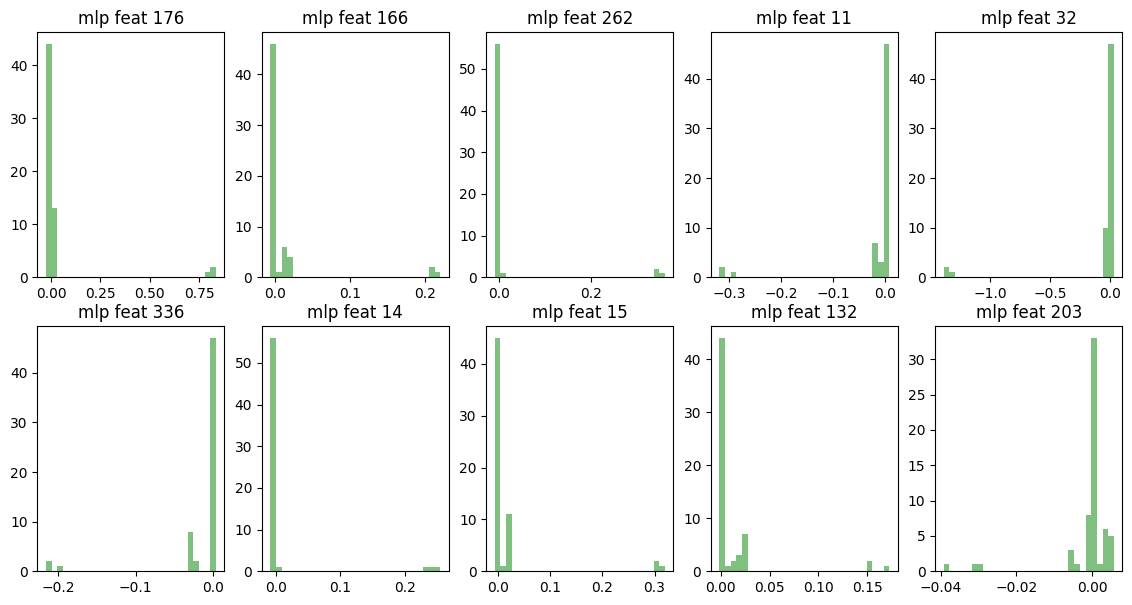

In [100]:
comp_name = utils.get_act_name("z",31)
_, cache_31_7_L455z = hooked_esm.run_with_cache(enc_L455, names_filter=comp_name)
del _
_, cache_31_7_F455z = hooked_esm.run_with_cache(enc_F455, names_filter=comp_name)

# difference of 31.7 between F455 and L455 at pos. 679
attn_31_7_diff_z = (cache_31_7_F455z[comp_name] - cache_31_7_L455z[comp_name])[:,679,7,:] 
attn_31_7_diff = einops.einsum(attn_31_7_diff_z, hooked_esm.W_O[31,7], "batch d_model, d_model d_head -> batch d_head")
mlp31_feats_score = mlp31_feats / mlp31_feats.norm() @ attn_31_7_diff.T

vals, inds = mlp31_feats_score.mean(dim=1).topk(k=10)
print(vals, inds)

fig, ax = plt.subplots(2,5,figsize=(14,7))
for i in range(2):
    for j in range(5):
        idx = i * 5 + j
        ax[i,j].hist(mlp31_feats_score[idx].cpu(), alpha=0.5, bins=30, color="green")
        ax[i,j].set_title(f"mlp feat {inds[idx]}")

plt.show()

del _
del cache_31_7_L455z
del cache_31_7_F455z
torch.cuda.empty_cache()

In [104]:
context_window = 262

for k in [262]:
    ti, ta = get_top_activating_indices(nmf.G_.cpu().detach(), k, 200)
    top_activations = [{'token': token_ds[i][0], 'activation': a, 'context': token_ds[i][1]} for i, a in zip(ti, ta)]
    print(f"###########{k}#############\n")
    for idx, i in enumerate(ti):
        aa_loc = i % MAX_LEN
        disp_context = token_ds[i][1]
        if len(disp_context) == context_window * 2 + 1:
            disp_context = f"{disp_context[:context_window]} {disp_context[context_window]} {disp_context[context_window+1:]}"
        
        print(f"{aa_loc}\t\t{token_ds[i][0]}\t\t{ta[idx]}\t\t{disp_context}")

###########262#############

246		R		0.008931012824177742		QTLLALHRSYLTPGG
4		F		0.00893132109194994		<cls>MFVFFVLLPLV
166		C		0.008931928314268589		VYSSANNCTFEYVSQ
4		F		0.008933015167713165		<cls>MFVFFVLLPLV
246		R		0.008933614008128643		QTLLALHRSYLTPGD
246		R		0.008935445919632912		QTLLALHRSYLTPGD
246		R		0.008936802856624126		QTLLALHRSYLTPGD
63		T		0.008940879255533218		LPFFSNVTWFHAIHV
909		I		0.008941682055592537		MAYRFNGIGVTQNVL
246		R		0.008941850624978542		QTLLALHRSYLTPGD
246		R		0.008946863003075123		QTLLALHRSYLTPGD
246		R		0.008950444869697094		QTLLALHRSYLTPGD
63		T		0.0089602405205369		LPFFSNVTWFHAIHV
246		R		0.008966092951595783		QTLLALHRSYLTPGG
246		R		0.008970637805759907		QTLLALHRSYLTPGD
909		I		0.008970796130597591		MAYRFNGIGVTQNVL
4		F		0.008971404284238815		<cls>MFVFFVLLPLV
909		I		0.008972528390586376		MAYRFNGIGVTQNVL
909		I		0.008976154029369354		MAYRFNGIGVTQNVL
63		T		0.008977280929684639		LPFFSNVTWFHAIHV
246		R		0.008977681398391724		QTLLALHRSYLTPGD
246		R		0.0089